Device:  cuda


Iteration 9: 100%|██████████| 100/100 [09:45<00:00,  5.86s/it, episode=1000, return=-864.310]


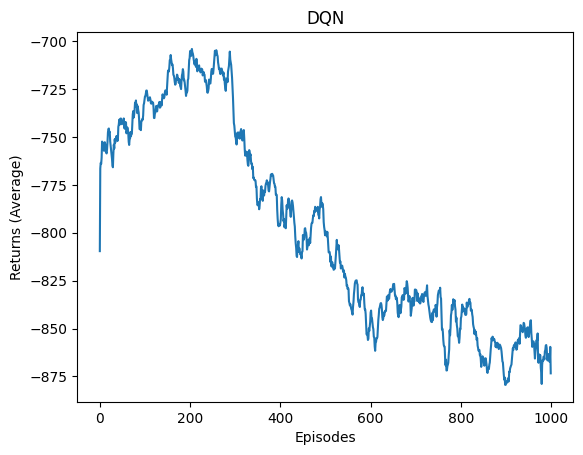

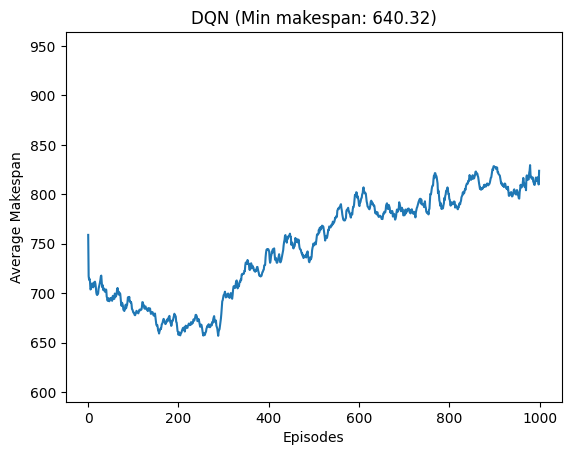

NameError: name 'JSRS' is not defined

In [1]:
from raw_DQN import DQN
import numpy as np
import random
import torch
from copy import deepcopy

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=128, state_dim=5*5*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(20)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)


In [3]:
from new_env import JSRS
final_dqn = raw_DQN.v_net
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
instance_names = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]
makespan_li = []
for instance in instance_names:
    env = JSRS.make(instance,'Data/train/'+instance+'.jsr')
    status = env.reset()
    while not status.done:
        next_state_values = []
        all_idx = list(range(len(status.available_operations)))
        random.shuffle(all_idx)
        for i in all_idx:
            env_tmp = deepcopy(env)
            available_operations = env_tmp.find_available_operations()
            if available_operations[i] is None:
                next_status = status
            else:
                next_status = env_tmp.step(available_operations[i], show_status=False)
            next_state = torch.tensor(raw_DQN.get_state_vec(next_status), dtype=torch.float).to(device)
            next_state_values.append(final_dqn(next_state).item())
        best_idx = all_idx[next_state_values.index(max(next_state_values))]
        action = status.available_operations[best_idx]
        next_status = env.step(action)
        status = next_status
    makespan_li.append(env.makespan)
print(makespan_li)
print(np.mean(makespan_li))

[550.1, 640.3, 631.8, 452.2, 232.2, 347.9, 403.2, 1128.6, 650.5, 410.6, 955.7, 972.1, 564.4, 1004.9, 1107.5, 1107.3, 958.2, 1061.5, 1992.9, 930.5, 2871.2, 4189.4, 4637.0, 3789.6, 3413.4]
1400.12


In [1]:
from raw_PPO import PPO
import numpy as np
import random
import torch
import torch.nn.functional as F
from new_env import JSRS

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_PPO = PPO(hidden_dim=128, state_d=5*5*12,action_d=5*5, actor_lr=5e-4, critic_lr=1e-5)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(20)]
return_list, makespan_list, instance_makespan = raw_PPO.train_loop(instance_list=instance_train,episodes=1000)
final_actor = raw_PPO.actor
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
instance_names = ['IS{}J{}M{}R{}'.format(3, 5, 5, i) for i in range(25)]
makespan_PPO = []
for instance in instance_names:
    env = JSRS.make(instance,'Data/train/'+instance+'.jsr')
    status = env.reset()
    while not status.done:
        operation = raw_PPO.get_state_vec(status)[0]
        state = np.array(raw_PPO.get_state_vec(status)[1])
        ope_raw = [(x[0], x[1]) if x is not None else None for x in status.available_operations]
        ope = []
        for oper in ope_raw:
            if oper not in ope:
                ope.append(oper)
        avail = [1 if elem in ope else 0 for elem in operation]
        avail = torch.tensor(avail, dtype=torch.float).to(device).unsqueeze(1)
        probs = final_actor(torch.tensor(state, dtype=torch.float).to(device)).view(-1, 1)
        probs = probs * avail + 1e-6
        action_probs = F.normalize(probs, p=1, dim=0)
        action_dist = torch.distributions.Categorical(action_probs.squeeze())
        action_num = action_dist.sample().item()
        action_node = operation[action_num]
        action = [item for item in status.available_operations if
                  item is not None and item[0] == action_node[0] and item[1] == action_node[1]]
        action = action[0] if len(action) == 1 else None
        next_status = env.step(action)
        status = next_status
    makespan_PPO.append(env.makespan)
print(makespan_PPO)
print(np.mean(makespan_PPO))

Device:  cuda


Iteration 0:   0%|          | 0/100 [00:00<?, ?it/s]C:\Users\ASUS\Desktop\JSRS\raw_PPO.py:196: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:233.)
  states = torch.tensor(transition_dict['states_vec'],
Iteration 2:  85%|████████▌ | 85/100 [20:03<03:32, 14.16s/it, episode=280, return=-2460.656]


KeyboardInterrupt: 

Device:  cuda


Iteration 9: 100%|██████████| 100/100 [18:26<00:00, 11.06s/it, episode=1000, return=-799.347, makespan=745.817]


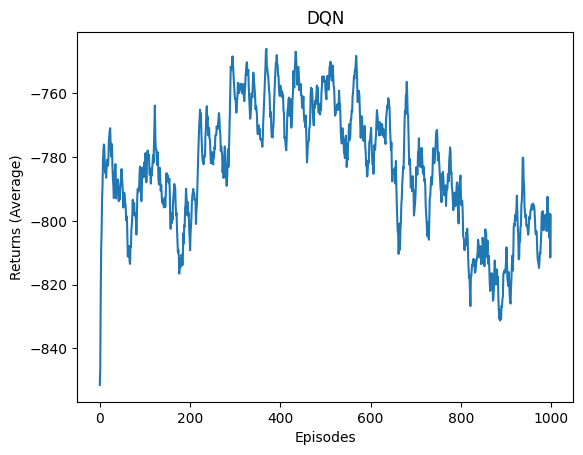

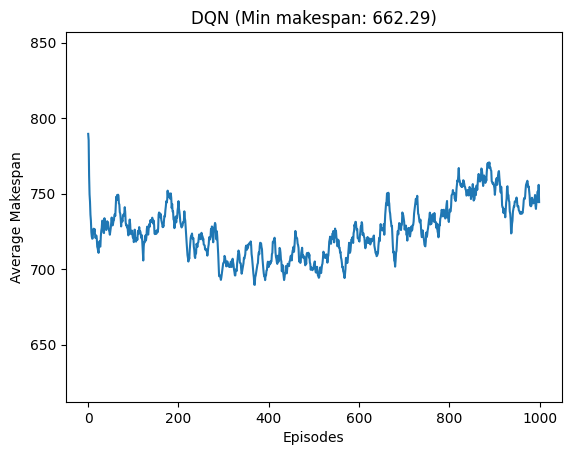

In [2]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=64, state_dim=10*5*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 10, 5, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

Device:  cuda


Iteration 9: 100%|██████████| 100/100 [04:57<00:00,  2.98s/it, episode=1000, return=-613.332]


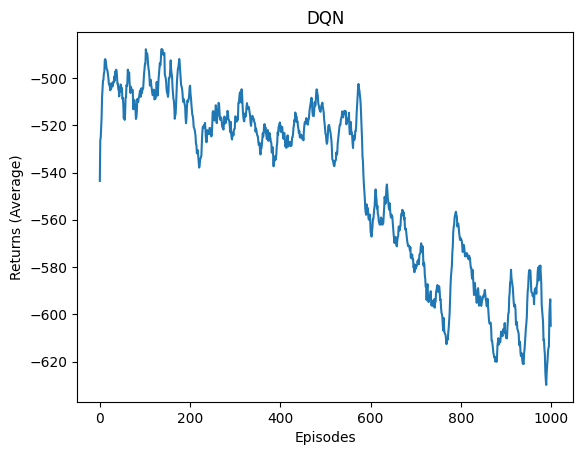

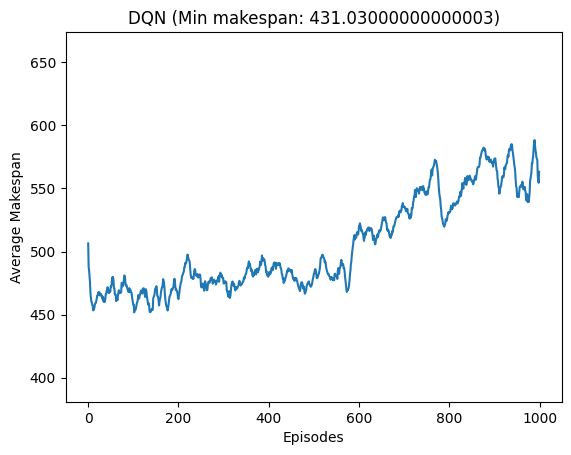

In [3]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=128, state_dim=5*5*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 5, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

Device:  cuda


Iteration 9: 100%|██████████| 100/100 [1:12:36<00:00, 43.56s/it, episode=1000, return=-1524.075, makespan=1429.121]


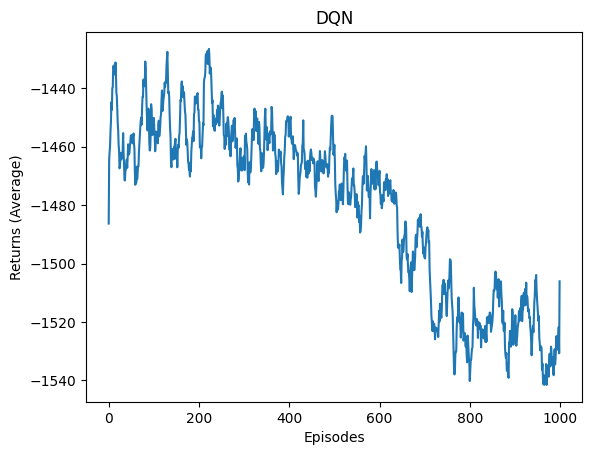

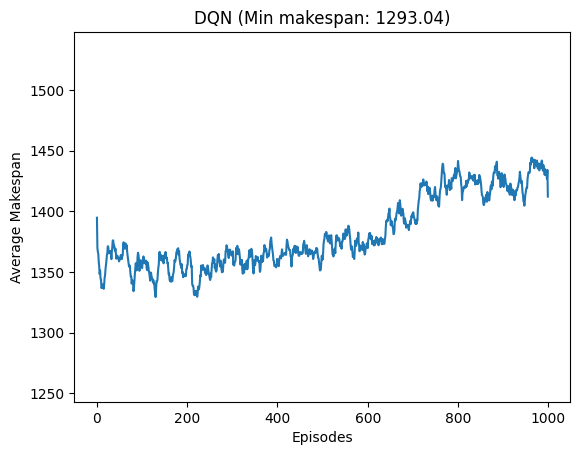

In [1]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=64, state_dim=20*5*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 20, 5, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

Device:  cuda


Iteration 9: 100%|██████████| 100/100 [10:07<00:00,  6.07s/it, episode=1000, return=-480.105, makespan=405.985]


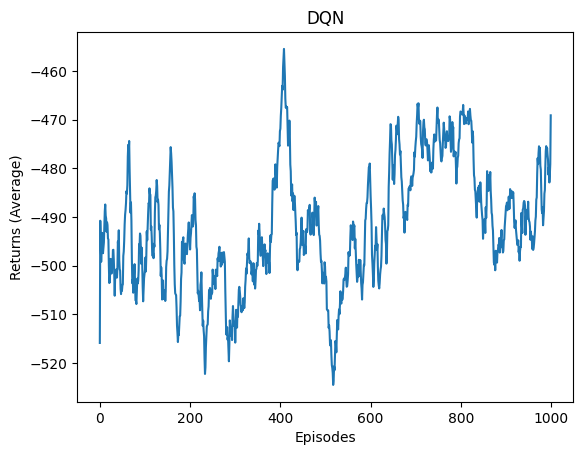

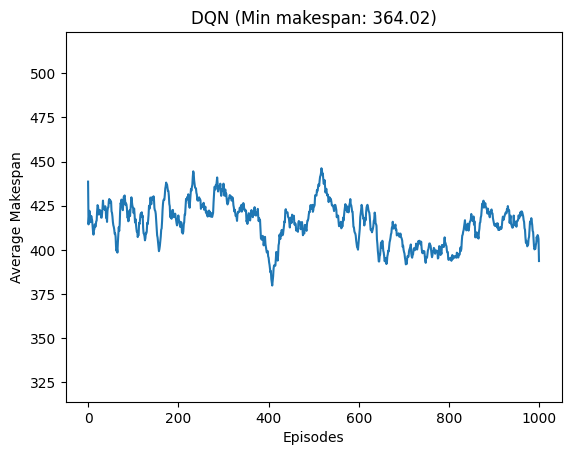

In [5]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=64, state_dim=5*10*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 5, 10, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

Device:  cuda


Iteration 9: 100%|██████████| 100/100 [27:37<00:00, 16.57s/it, episode=1000, return=-569.230, makespan=473.714]


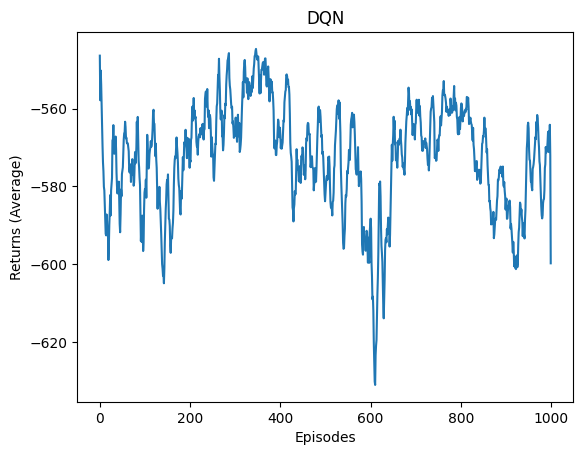

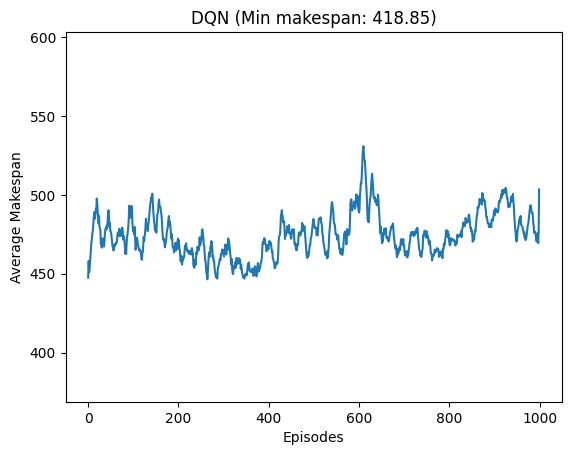

In [1]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=128, state_dim=10*10*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 10, 10, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

In [2]:
from raw_DQN import DQN
import numpy as np
import random
import torch

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
raw_DQN = DQN(hidden_dim=128, state_dim=20*10*12,learning_rate=1e-4)
instance_train = ['IS{}J{}M{}R{}'.format(3, 20, 10, i+10) for i in range(10)]
return_list, makespan_list, instance_makespan = raw_DQN.train_loop(instance_list=instance_train,episodes=1000)

Device:  cuda


Iteration 0:  13%|█▎        | 13/100 [16:01<1:47:12, 73.94s/it, episode=10, return=-823.611, makespan=702.161]


KeyboardInterrupt: 